# Introduction to Digital Sampling

Sampling is the fundamental process of converting continuous data (such as real-world scenes, analog signals, or mathematical geometries) into a discrete digital format. 

This notebook demonstrates digital sampling through two core perspectives:
1. **Spatial Sampling in 2D Images:** Discretizing a continuous canvas into a finite grid of pixels (rasterization).
2. **1D Signal Sampling & Reconstruction:** Extracting a continuous waveform slice from our data, sampling it at regular intervals, and reconstructing it using a zero-order hold interpolation pattern.

## 1. Spatial Sampling in 2D Images

In a digital imaging system, continuous spatial geometry must be broken down into discrete matrix cells. Below, we define the operations to perform this discretization:
* **Aspect Ratio Adjustment:** Trimming excess pixels so the image dimensions divide perfectly by our chosen grid size.
* **Grid Overlay:** Marking uniform cells along with their exact mathematical centers (the coordinates where our sensor evaluates space).
* **Pixelation:** Simulating the sampling result by filling each cell entirely with the color captured at its center point.

In [83]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from math import ceil

def load_image(image_path):
    """
    Loads an image while preserving its alpha (transparency) channel if present.
    """
    image = cv2.imread(image_path, cv2.IMREAD_UNCHANGED)
    if image is None:
        print("Error: Image could not be loaded. Verify the file path.")
        return None
    return image

def crop_vertical_remainder(image, div_x, crop_top=True):
    """
    Calculates individual grid cell size using div_x and crops out any vertical 
    pixel remainder from either the top or bottom edge to ensure a perfect fit.
    """
    height, width = image.shape[:2]
    box_size = width / div_x
    max_divisions_y = int(height / box_size)
    perfect_height = ceil(max_divisions_y * box_size)
    leftover_pixels = height - perfect_height
    print(f"Image dimensions: {width}x{height} pixels")
    print(f"Number of divisions in X: {div_x}, box size: {box_size:.2f} pixels")
    print(f"Max divisions in Y: {height / box_size:.2f} (integer: {max_divisions_y})")
    print(f"Perfect height: {max_divisions_y * box_size:.2f} pixels, (integer: {perfect_height})")
    print(f"Leftover pixels: {leftover_pixels} pixels")
    
    cropped_image = image.copy()
    if leftover_pixels > 0:
        if crop_top:
            cropped_image = image[leftover_pixels:height, 0:width, ...]
        else:
            cropped_image = image[0:perfect_height, 0:width, ...]
        return cropped_image
    
    return cropped_image

def pixelate_image(image, div_x=10):
    """
    Discretizes the image into a flat-colored mosaic grid based solely on the 
    color sampled at the absolute center pixel of each distinct block quadrant.
    """
    height, width = image.shape[:2]
    box_size = width / div_x
    max_divisions_y = int(height / box_size)

    for row in range(max_divisions_y):
        for col in range(div_x):
            # Compute exact center coordinate of the current sampling cell
            center_x = int((col + 0.5) * box_size)
            center_y = int((row + 0.5) * box_size)
            
            # Clamp within array index limits
            center_x = min(center_x, width - 1)
            center_y = min(center_y, height - 1)
            
            # Sample the original source color at the exact center location
            detected_color = image[center_y, center_x]
            
            # Define target bounding borders of the pixel block
            x_start = int(col * box_size)
            y_start = int(row * box_size)
            x_end = int((col + 1) * box_size)
            y_end = int((row + 1) * box_size)
            
            # Fill the entire cell with the single discrete sampled sample value
            color_tuple = tuple(int(val) for val in detected_color)
            cv2.rectangle(image, (x_start, y_start), (x_end, y_end), color_tuple, cv2.FILLED)
            
    return image

def overlay_grid(image, div_x=10, color_rgb=(0, 255, 0), thickness=1, draw_points=True, point_radius=3):
    """
    Overlays sampling grid boundaries and explicitly draws the evaluation 
    points (the mathematical centers) corresponding to each discrete sample site.
    """
    height, width = image.shape[:2]
    r, g, b = color_rgb
    
    if image.shape[2] == 4:
        color_bgr = (b, g, r, 255)
    else:
        color_bgr = (b, g, r)

    box_size = width / div_x
    print(f"Overlaying grid with box size: {box_size:.2f} pixels")
    max_divisions_y = int(height / box_size)
    print(f"Max divisions in Y: {height / box_size:.2f} (integer: {max_divisions_y})")

    # 1. Draw vertical gridlines
    for i in range(1, div_x):
        x = int(i * box_size)
        cv2.line(image, (x, 0), (x, height), color_bgr, thickness)

    # 2. Draw horizontal gridlines
    for i in range(1, max_divisions_y):
        y = int(i * box_size)
        cv2.line(image, (0, y), (width, y), color_bgr, thickness)

    # 3. Draw discrete center points
    if draw_points:
        for row in range(max_divisions_y):
            for col in range(div_x):
                center_x = int((col + 0.5) * box_size)
                center_y = int((row + 0.5) * box_size)
                cv2.circle(image, (center_x, center_y), point_radius, color_bgr, cv2.FILLED)

    return image

def display_cv2_image(image, title=""):
    """
    Helper function to inline display OpenCV BGR/BGRA matrices inside Jupyter via matplotlib.
    Preserves transparency against a black background.
    """
    # 1. Creamos la figura especificando que su fondo sea negro (para los márgenes)
    fig, ax = plt.subplots(figsize=(6, 6), facecolor='black')
    
    # 2. Convertimos el espacio de color según los canales
    if image.shape[2] == 4:
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGRA2RGBA)
    else:
        rgb_image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        
    # 3. Forzamos a que el fondo del área de dibujo también sea negro
    ax.set_facecolor('black')
    ax.imshow(rgb_image)
    
    # 4. Estilizados el título en blanco para que contraste con el fondo negro
    ax.set_title(title, color='white', fontsize=12, pad=10)
    ax.axis('off')
    
    plt.show()

### Executing 2D Spatial Sampling
Here we target a clean number of uniform divisions (`divisions_x = 9`) across the horizontal span, aligning our geometry bounds and rendering them sequentially inside the cell context display window.

In [84]:
file_path = 'original.png'
image = load_image(file_path)

The number of divisions can be adjusted to observe how the sampling density affects the final output. A higher number of divisions will yield a more accurate representation of the original image, while a lower number will result in a more pixelated and less detailed output.

In [85]:
DIVISIONS_X = 9

Let's proceed to visualize the sampling process step by step. Firstly, the image is loaded and cropped to ensure it aligns with the specified grid divisions.

The image obtained represents the geometry itself being rendered.

Image dimensions: 558x447 pixels
Number of divisions in X: 9, box size: 62.00 pixels
Max divisions in Y: 7.21 (integer: 7)
Perfect height: 434.00 pixels, (integer: 434)
Leftover pixels: 13 pixels


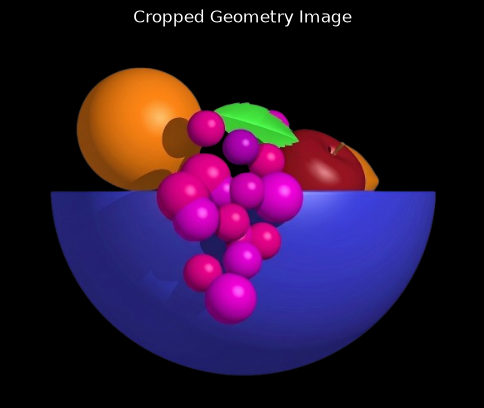

In [86]:
image = crop_vertical_remainder(image, div_x=DIVISIONS_X, crop_top=True)
display_cv2_image(image, title="Cropped Geometry Image")

Next, since our monitor is a discrete pixel array, the image is sampled. The sampling grid is overlaid in yellow, and the evaluation points are drawn as small yellow circles. Each evaluation point corresponds to the center of a grid cell, where the color is sampled.

Overlaying grid with box size: 62.00 pixels
Max divisions in Y: 7.00 (integer: 7)


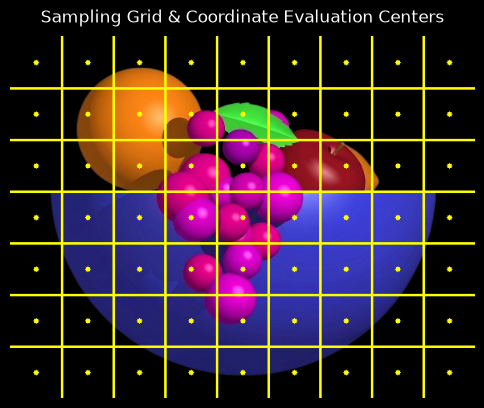

In [87]:
gridded = overlay_grid(image.copy(), div_x=DIVISIONS_X, color_rgb=(255, 255, 0), thickness=2, draw_points=True, point_radius=3)
display_cv2_image(gridded, title="Sampling Grid & Coordinate Evaluation Centers")

Finally, the sampled image is reconstructed by filling each grid cell with the color sampled at its center, resulting in a pixelated version of the original geometry.

As the reader can observe, the sampling process effectively captures the essence of the original image while introducing a level of abstraction due to the discrete nature of digital representation.

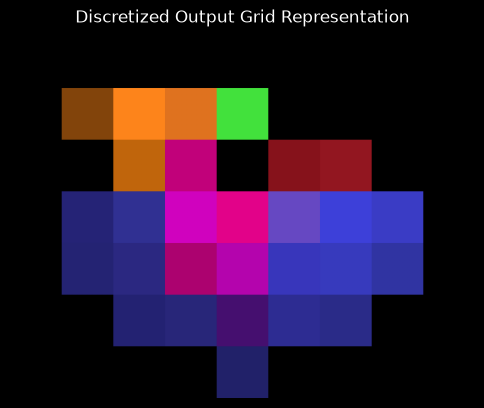

In [88]:
pixelated = pixelate_image(image.copy(), div_x=DIVISIONS_X)
display_cv2_image(pixelated, title="Discretized Output Grid Representation")

## 2. 1D Signal obtention from a image

Images can be viewed as continuous waves or functions. If we isolate a single horizontal slice cross-section, the spatial location $x$ maps onto a brightness intensity value $y$.

We drop a tracking vector marker axis across our image at a set percentage level to extract and view this continuous waveform path, then capture uniform sampling frames from it.

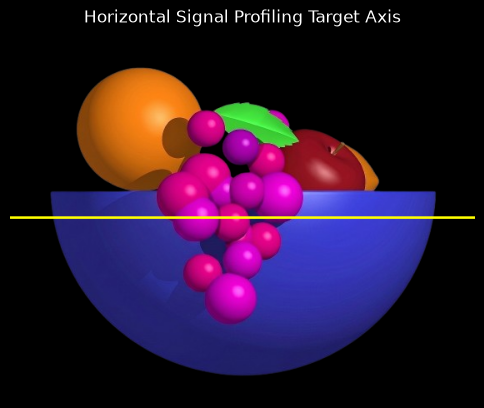

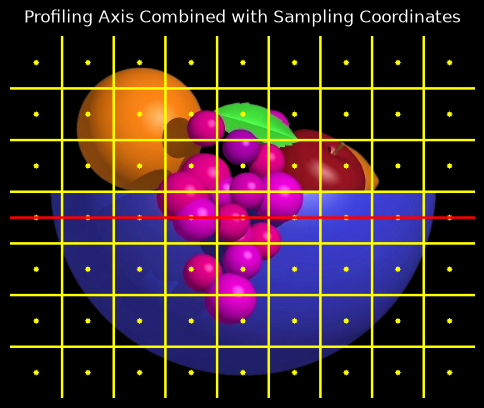

In [89]:
def draw_horizontal_percentage_line(image, percentage_y, color_rgb=(255, 0, 0), thickness=2):
    """
    Draws a horizontal line axis marker across the canvas layout at a designated height index percentage.
    """
    height, width = image.shape[:2]
    
    if not (0.0 <= percentage_y <= 1.0):
        print(f"Error: Percentage value ({percentage_y}) must be between 0.0 and 1.0.")
        return image

    target_y = int(percentage_y * height)
    target_y = min(target_y, height - 1)
    
    r, g, b = color_rgb
    if image.shape[2] == 4:
        color_bgr = (b, g, r, 255)
    else:
        color_bgr = (b, g, r)

    cv2.line(image, (0, target_y), (width, target_y), color_bgr, thickness)
    
    return image


max_divisions_y = int(image.shape[0] / int(image.shape[1] / DIVISIONS_X))
TARGET_ROW = int((max_divisions_y-1) / 2)   # It can be any row index from 0 to max_divisions_y - 1
PERCENTAGE_Y = (TARGET_ROW + 0.5) / max_divisions_y

with_line = draw_horizontal_percentage_line(image.copy(), percentage_y=PERCENTAGE_Y, color_rgb=(255, 255, 0), thickness=2)
display_cv2_image(with_line, title="Horizontal Signal Profiling Target Axis")

with_line_and_grid = draw_horizontal_percentage_line(gridded.copy(), percentage_y=PERCENTAGE_Y, color_rgb=(255, 0, 0), thickness=2)
display_cv2_image(with_line_and_grid, title="Profiling Axis Combined with Sampling Coordinates")

### Continuous Wave Extraction vs. Discrete Oscilloscope Plots

We process the slice line data to calculate luminance profile data:
1. **`profile_only`:** Plots the continuous raw luminancy wave spectrum profile across spatial locations.
2. **`profile_guides`:** Maps our exact uniform sampling interval windows on top of the continuous profile wave line curve.
3. **`sampled`:** The mathematical system drops everything else and registers only discrete instantaneous data spikes.
4. **`reconstructed_constant_piecewise`:** Employs a zero-order hold (nearest-neighbor step matching) to turn our discrete numbers back into a continuous block waveform.

In [90]:
def analyze_image_brightness(image, base_percentage_y=0.75):
    """
    Scans the image line path across a designated relative height axis
    and extracts continuous structural coordinate vectors of color brilliance.
    """
    height, width = image.shape[:2]
    has_alpha = image.shape[2] == 4
    base_y_pixel = int(base_percentage_y * height)

    axis_x = np.arange(width)
    axis_y = np.zeros(width)

    for x in range(width):
        pixel = image[min(base_y_pixel, height - 1), x]

        # 1. Fallback zero level calculation for fully transparent pixels
        if has_alpha and pixel[3] == 0:
            axis_y[x] = 0.0
            continue

        # 2. Standard luminance weighting transform formula matrix metrics
        b_val, g_val, r_val = pixel[0], pixel[1], pixel[2]
        brightness = (0.299 * r_val + 0.587 * g_val + 0.114 * b_val) / 255.0
        axis_y[x] = brightness

    return axis_x, axis_y, width

def generate_profile_plot(image, base_percentage_y=0.75, color_rgb=(255, 255, 0), 
                          mode='profile_only', num_samples=12):
    """
    Plots and models discrete transforms over the continuous image luminance values.
    """
    axis_x, axis_y, width = analyze_image_brightness(image, base_percentage_y)

    plt.style.use('dark_background')
    fig, ax = plt.subplots(figsize=(10, 4))

    color_r, color_g, color_b = color_rgb
    color_hex = '#{:02X}{:02X}{:02X}'.format(color_r, color_g, color_b)

    # Calculate center sampling step parameters matches
    if mode in ['profile_guides', 'sampled', 'reconstructed_constant_piecewise']:
        box_size = width / num_samples
        multipliers = np.arange(num_samples) + 0.5
        x_samples = (multipliers * box_size).astype(int)
        x_samples = np.clip(x_samples, 0, width - 1)
        y_samples = axis_y[x_samples]

    # Output graphics mapping depending on target configurations settings
    if mode == 'profile_guides':
        ax.plot(axis_x, axis_y, color=color_hex, linewidth=2)
        for x_s in x_samples:
            ax.axvline(x=x_s, color='white', linestyle='--', alpha=0.3, linewidth=1)
        ax.set_title("Luminance Wave Profile with Sampling Window Guides")

    elif mode == 'sampled':
        ax.bar(x_samples, y_samples, width=width * 0.008, color=color_hex, align='center')
        ax.set_title("Discrete Quantized Samples (Impulse Train Tracking)")

    elif mode == 'reconstructed_constant_piecewise':
        ax.step(x_samples, y_samples, where='mid', color=color_hex, linewidth=2)
        ax.scatter(x_samples, y_samples, color='white', s=15, zorder=3, alpha=0.7)
        ax.set_title("Signal Reconstruction via Zero-Order Hold (ZOH)")
    else:
        if mode != 'profile_only':
            print(f"Warning: Mode '{mode}' not verified. Defaulting to 'profile_only'.")
        ax.plot(axis_x, axis_y, color=color_hex, linewidth=2)
        ax.set_title("Continuous Analogue Luminance Waveform Extract")

    ax.set_ylim(-0.05, 1.05)
    ax.set_xlim(-width * 0.02, width * 1.02)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('white')
    ax.spines['bottom'].set_color('white')
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_linewidth(2)
    ax.set_xticks([])
    ax.set_yticks([])
    
    plt.tight_layout()
    plt.show()

From the 2D image that we are processing, we can obtain the following 1D continous signal.

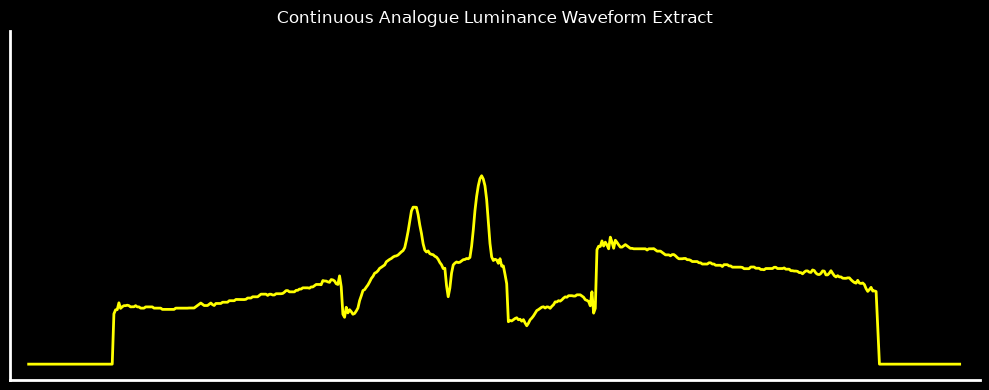

In [91]:
generate_profile_plot(image, base_percentage_y=PERCENTAGE_Y, color_rgb=(255, 255, 0), mode='profile_only', num_samples=DIVISIONS_X)

### Sampling in 1D Signals

As explained in the first section, a signal first has to be sampled in order to be stored and reconstructed. The sampled signal is the following:

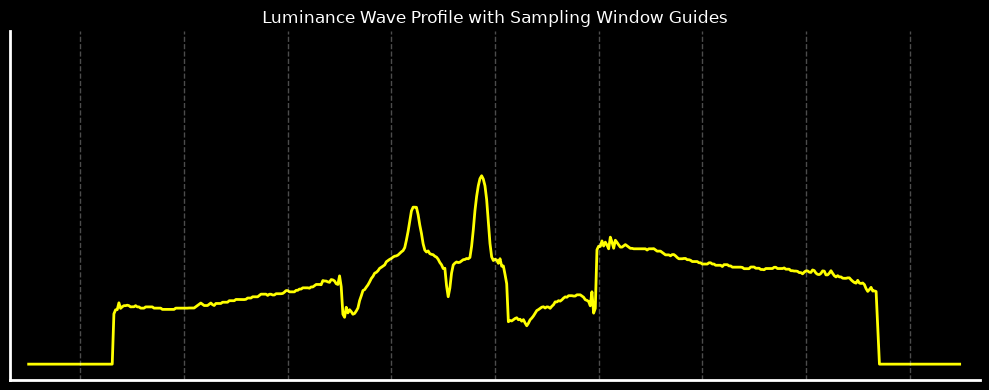

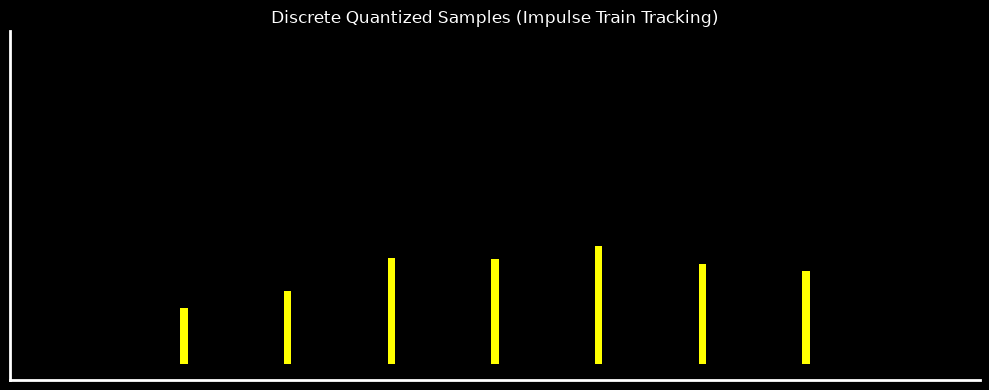

In [92]:
for mode in ['profile_guides', 'sampled']:
    generate_profile_plot(image, base_percentage_y=PERCENTAGE_Y, color_rgb=(255, 255, 0), mode=mode, num_samples=DIVISIONS_X)

Once the signal is sampled, it can be reconstructed. As a first approach, a constant piecewise reconstruction is performed, which is a zero-order hold interpolation. This method holds each sampled value constant until the next sample is reached, resulting in a step-like waveform.

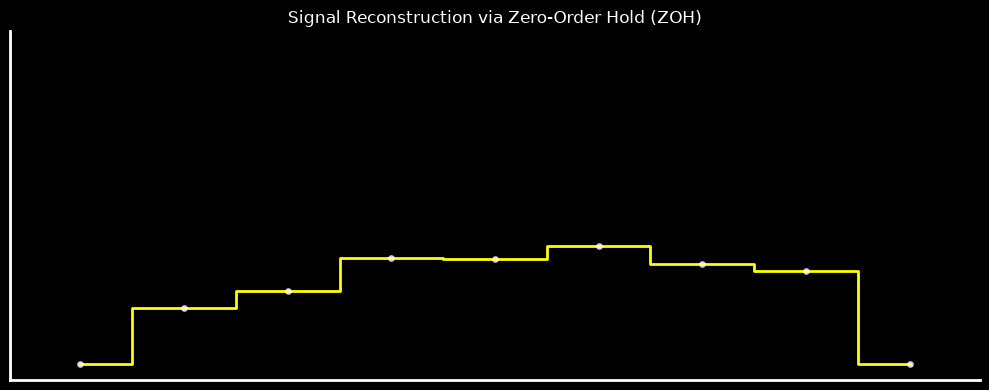

In [93]:
for mode in ['reconstructed_constant_piecewise']:
    generate_profile_plot(image, base_percentage_y=PERCENTAGE_Y, color_rgb=(255, 255, 0), mode=mode, num_samples=DIVISIONS_X)

As the reader can observe, the sampling process effectively captures the essence of the original signal while introducing a level of abstraction due to the discrete nature of digital representation. For instance, the two important peaks of the original signal do not appear in the sampled signal, which is a consequence of the sampling theorem.